In [2]:
pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 7.9 MB/s eta 0:00:05
   - -------------------------------------- 1.8/38.1 MB 5.2 MB/s eta 0:00:08
   -- ------------------------------------- 2.4/38.1 MB 3.9 MB/s eta 0:00:10
   --- ------------------------------------ 2.9/38.1 MB 4.4 MB/s eta 0:00:09
   ---- ----------------------------------- 4.2/38.1 MB 4.3 MB/s eta 0:00:08
   ----- ---------------------------------- 5.2/38.1 MB 4.1 MB/s eta 0:00:08
   ------ --------------------------------- 6.0/38.1 MB 4.1 MB/s eta 0:00:08
   ------- -------------------------------- 6.8/38.1 MB 4.1 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/38.1 MB 4.1 MB/s eta 0:00:08
   -------- ------------------------------- 8.4/38.1 MB 4.0 MB/s eta 0:00:08
   --------- ------------------------------ 9.2/38.1 MB 4.0 MB/s eta 0:00:08
   ---------- ----------------------------- 10.0/38.1 MB 4.0 MB/s eta 0:00:08
   --

In [4]:
import joblib
import shap
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.preprocessing import load_and_preprocess_data

In [5]:
model = joblib.load(
    "../models/best_xgboost.pkl"
)

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

X_train, X_test, y_train, y_test, _ = (
    load_and_preprocess_data(
        "../data/deployment_data_engineered.csv"
    )
)

In [6]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

In [10]:
print(type(X_test))

<class 'numpy.ndarray'>


In [12]:
feature_names = preprocessor.get_feature_names_out()

In [13]:
feature_names

array(['num__systems_impacted', 'num__num_files_changed',
       'num__deployment_hour', 'num__engineer_experience',
       'num__historical_failures', 'num__dependency_count',
       'num__rollback_required', 'num__test_coverage',
       'num__complexity_score', 'num__after_hours',
       'num__weekend_deployment', 'cat__deployment_day_Friday',
       'cat__deployment_day_Monday', 'cat__deployment_day_Saturday',
       'cat__deployment_day_Sunday', 'cat__deployment_day_Thursday',
       'cat__deployment_day_Tuesday', 'cat__deployment_day_Wednesday',
       'cat__change_type_Application', 'cat__change_type_Database',
       'cat__change_type_Infrastructure', 'cat__change_type_Network'],
      dtype=object)

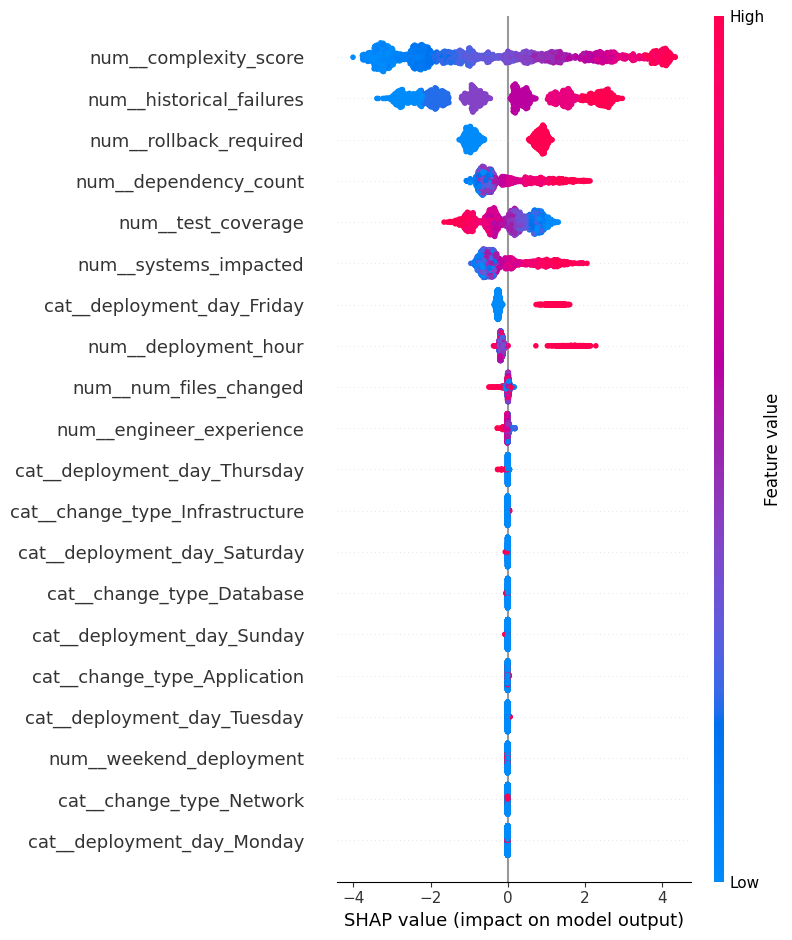

In [14]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names = feature_names,
    show=False
)

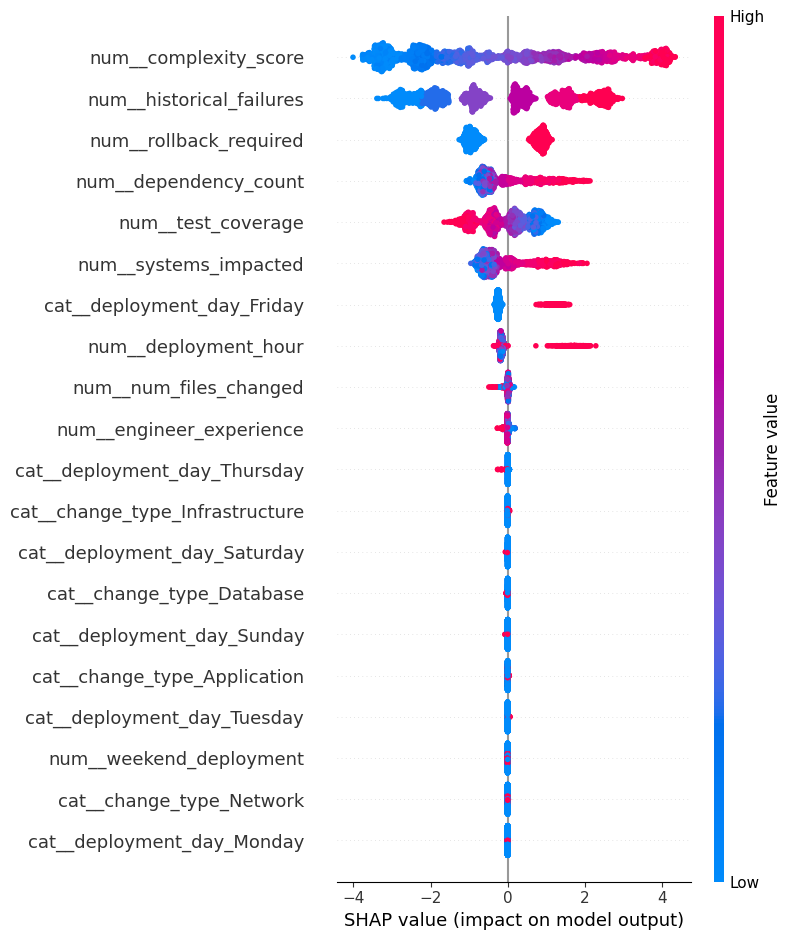

In [15]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    feature_names = feature_names,
    show=False
)

plt.savefig(
    "../reports/shap_global_importance.png",
    bbox_inches="tight"
)

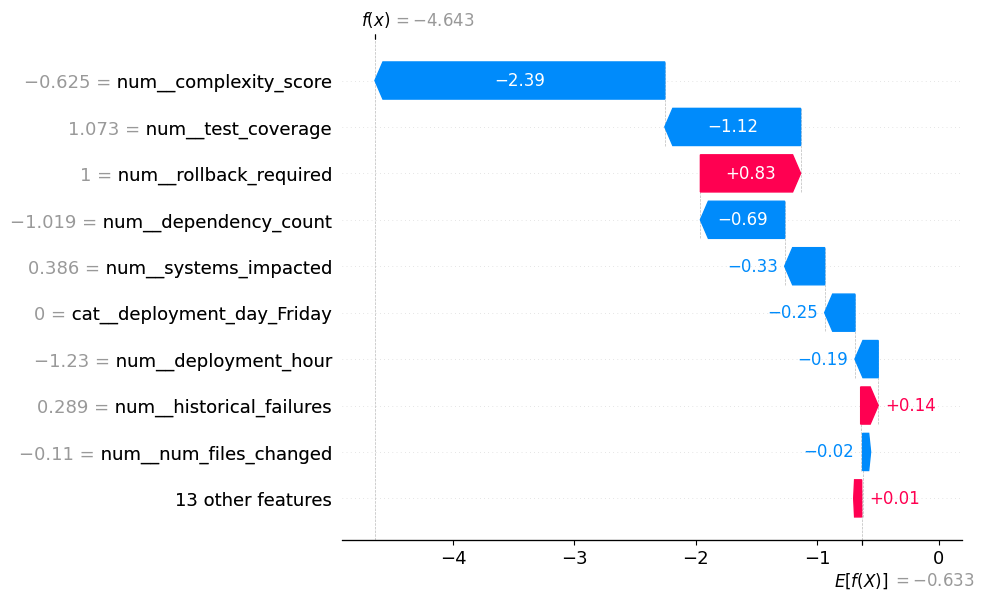

In [16]:
sample_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        feature_names = feature_names,
        base_values=explainer.expected_value,
        data=X_test[sample_index]
    )
)

In [17]:
plt.savefig(
    "../reports/shap_local_explanation.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [18]:
!pip install mlflow

  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.8 MB 5.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/10.8 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/10.8 MB 4.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.7/10.8 MB 4.1 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/10.8 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/10.8 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 6.0/10.8 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 6.8/10.8 MB 4.0 MB/s eta 0:00:01
   ---------------------------- ----------- 7.6/10.8 MB 4.0 MB/s eta 0:00:01
   -------------------